In [1]:
#instalamos lo necesario para hacer graficas
!pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance, accuracy_score
from sklearn.preprocessing import MinMaxScaler

from itertools import cycle
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import seaborn as sns
import matplotlib.pyplot as plt

### predicciones ETHERIUM

In [2]:
import yfinance as yf

# Definir el ticker de la criptomoneda
crypto = "ETH-USD"

In [3]:
# Descargar datos históricos (últimos 6 meses, por ejemplo)
ethereumdf = yf.download(crypto,  start="2020-01-01", end="2026-04-25")

/tmp/ipykernel_17124/884570191.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ethereumdf = yf.download(crypto,  start="2020-01-01", end="2026-04-25")
[*********************100%***********************]  1 of 1 completed


In [4]:
# Renombrar las columnas para prescindir del nombre de la criptomoneda
ethereumdf.columns = [col[0] if isinstance(col, tuple) else col for col in ethereumdf.columns]

# Asegurarte de que el índice sea la columna `Date`
ethereumdf.reset_index(inplace=True)

# Renombrar 'Date' si es necesario
ethereumdf.rename(columns={'index': 'Date'}, inplace=True)

# Mostrar el DataFrame procesado
print(ethereumdf.head())

        Date       Close        High         Low        Open       Volume
0 2020-01-01  130.802002  132.835358  129.198288  129.630661   7935230330
1 2020-01-02  127.410179  130.820038  126.954910  130.820038   8032709256
2 2020-01-03  134.171707  134.554016  126.490021  127.411263  10476845358
3 2020-01-04  135.069366  136.052719  133.040558  134.168518   7430904515
4 2020-01-05  136.276779  139.410202  135.045624  135.072098   7526675353


In [5]:

ethereumdf = ethereumdf.rename(columns={'Date': 'date','Open':'open','High':'high','Low':'low','Close':'close',
                                'Adj Close':'adj_close','Volume':'volume'})
ethereumdf.head()

,date,close,high,low,open,volume
0,2020-01-01,130.802002,132.835358,129.198288,129.630661,7935230330
1,2020-01-02,127.410179,130.820038,126.954910,130.820038,8032709256
2,2020-01-03,134.171707,134.554016,126.490021,127.411263,10476845358
3,2020-01-04,135.069366,136.052719,133.040558,134.168518,7430904515
4,2020-01-05,136.276779,139.410202,135.045624,135.072098,7526675353


In [6]:
ethereumdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2306 entries, 0 to 2305
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2306 non-null   datetime64[ns]
 1   close   2306 non-null   float64       
 2   high    2306 non-null   float64       
 3   low     2306 non-null   float64       
 4   open    2306 non-null   float64       
 5   volume  2306 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 108.2 KB


In [7]:
ClosedfEth = ethereumdf[['date','close']]
print("Datos cierre:", ClosedfEth.shape)

Datos cierre: (2306, 2)


In [8]:
ClosedfEth = ethereumdf[['date','close']].copy()
ClosedfEth = ClosedfEth[ClosedfEth['date'] > '2020-10-01']
close_stock = ClosedfEth.copy()
print("Datos totales encontrados para la predicción: ",ClosedfEth.shape[0])

Datos totales encontrados para la predicción:  2031


In [9]:
del ClosedfEth['date']
scaler=MinMaxScaler(feature_range=(0,1))
ClosedfEth=scaler.fit_transform(np.array(ClosedfEth).reshape(-1,1))
print(ClosedfEth.shape)

(2031, 1)


In [10]:
ClosedfEth

array([[0.00120767],
       [0.00127073],
       [0.00261955],
       ...,
       [0.45323626],
       [0.44330999],
       [0.4397862 ]])

In [11]:
len(ClosedfEth)

2031

In [12]:
training_size=int(len(ClosedfEth)*0.9)

In [13]:
len(ClosedfEth)-training_size

204

In [14]:
test_size=len(ClosedfEth)-training_size
train_data,test_data=ClosedfEth[0:training_size,:],ClosedfEth[training_size:len(ClosedfEth),:1]
print("datos de entrenamiento: ", train_data.shape)
print("informacion test: ", test_data.shape)

datos de entrenamiento:  (1827, 1)
informacion test:  (204, 1)


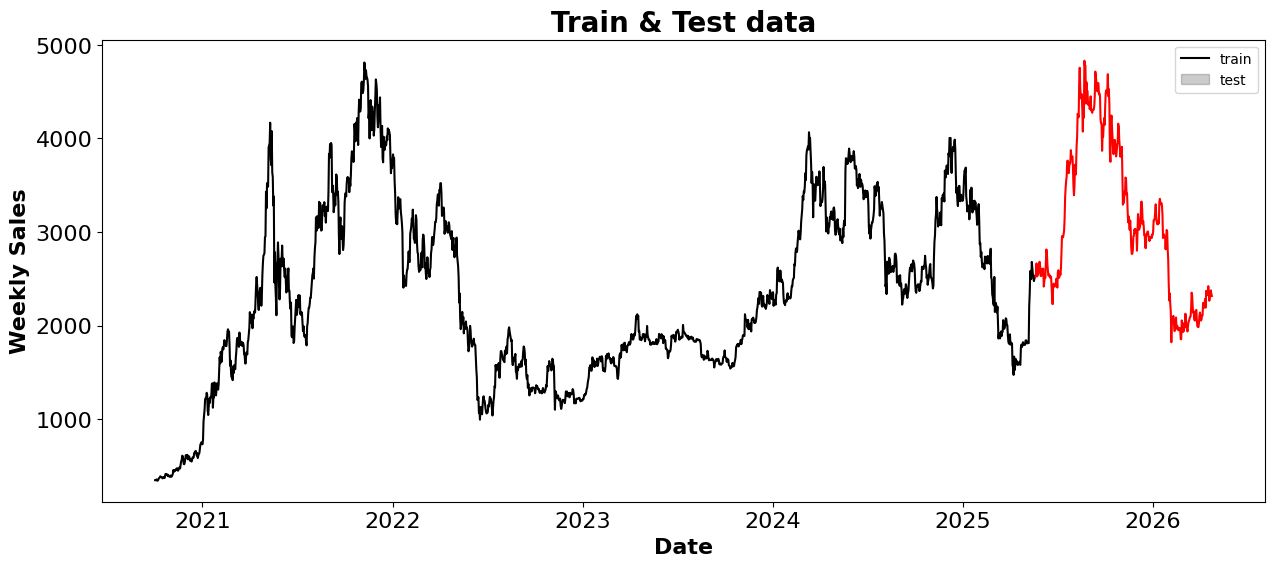

In [15]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(x = close_stock['date'][:1691], y = close_stock['close'][:1691], color = 'black')
sns.lineplot(x = close_stock['date'][1691:], y = close_stock['close'][1691:], color = 'red')

# Formato
ax.set_title('Train & Test data', fontsize = 20, loc='center', fontdict=dict(weight='bold'))
ax.set_xlabel('Date', fontsize = 16, fontdict=dict(weight='bold'))
ax.set_ylabel('Weekly Sales', fontsize = 16, fontdict=dict(weight='bold'))
plt.tick_params(axis='y', which='major', labelsize=16)
plt.tick_params(axis='x', which='major', labelsize=16)
plt.legend(loc='upper right' ,labels = ('train', 'test'))

In [16]:
# convertir una matriz de valores en una matriz de conjuntos de datos
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

In [17]:
time_step = 10
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test", y_test.shape)

X_train:  (1816, 10)
y_train:  (1816,)
X_test:  (193, 10)
y_test (193,)


In [18]:
!pip install xgboost

In [19]:
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=1000)
model.fit(X_train, y_train, verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [20]:
import math
predictions = model.predict(X_test)
print("Error absoluto medio - MAE : " + str(mean_absolute_error(y_test, predictions)))
print("Error cuadrático medio - RMSE : " + str(math.sqrt(mean_squared_error(y_test, predictions))))

Error absoluto medio - MAE : 0.02096815702885999
Error cuadrático medio - RMSE : 0.02744588887614646


In [21]:
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

train_predict = train_predict.reshape(-1,1)
test_predict = test_predict.reshape(-1,1)

print("Datos para el entrenamiento:", train_predict.shape)
print("Datos para el test:", test_predict.shape)

Datos para el entrenamiento: (1816, 1)
Datos para el test: (193, 1)


In [22]:
train_predict

array([[0.00910545],
       [0.00910545],
       [0.00910545],
       ...,
       [0.8621502 ],
       [0.848679  ],
       [0.8928367 ]], dtype=float32)

In [23]:
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
original_ytrain = scaler.inverse_transform(y_train.reshape(-1,1))
original_ytest = scaler.inverse_transform(y_test.reshape(-1,1))

In [24]:
print(train_predict)

[[ 381.70416]
 [ 381.70416]
 [ 381.70416]
 ...
 [4212.3296 ]
 [4151.8364 ]
 [4350.128  ]]


In [25]:
# predicciones del entrenamiento para su visualización

look_back=time_step
trainPredictPlot = np.empty_like(ClosedfEth)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
print("Previsión de datos de entrenamiento: ", trainPredictPlot.shape)

# predicciones de test
testPredictPlot = np.empty_like(ClosedfEth)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(ClosedfEth)-1, :] = test_predict
print("Previsión de datos de test: ", testPredictPlot.shape)

names = cycle(['Precio de cierre original','Precio de cierre previsto, train','Precio de cierre previsto, test'])

plotdf = pd.DataFrame({'date': close_stock['date'],
                       'original_close': close_stock['close'],
                      'train_predicted_close': trainPredictPlot.reshape(1,-1)[0].tolist(),
                      'test_predicted_close': testPredictPlot.reshape(1,-1)[0].tolist()})

fig = px.line(plotdf,x=plotdf['date'], y=[plotdf['original_close'],plotdf['train_predicted_close'],
                                          plotdf['test_predicted_close']],
              labels={'value':'Close price','date': 'Date'})
fig.update_layout(title_text='precio cierre original vs precio previsto',
                  plot_bgcolor='white', font_size=15, font_color='black',legend_title_text='Close Price')
fig.for_each_trace(lambda t:  t.update(name = next(names)))

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

Previsión de datos de entrenamiento:  (2031, 1)
Previsión de datos de test:  (2031, 1)


## Prediccion para un dia

In [26]:
import numpy as np
import pandas as pd
import plotly.express as px
from itertools import cycle
from sklearn.metrics import mean_absolute_error

# ===== 1) Predicción recursiva a h pasos =====
def predict_h_steps(model, x_row, h):
    """
    x_row: una fila de X_test (shape: (time_step,)) en escala NORMALIZADA
    devuelve la predicción t+h (NORMALIZADA) usando predicción recursiva
    """
    window = x_row.copy()
    for _ in range(h):
        yhat = model.predict(window.reshape(1, -1))[0]  # normalizado
        window = np.roll(window, -1)
        window[-1] = yhat
    return yhat

# ===== 2) Generar test_predict_1 (normalizado -> real) =====
h = 1
test_predict_1_scaled = np.array([predict_h_steps(model, X_test[i], h) for i in range(len(X_test))]).reshape(-1, 1)
test_predict_1 = scaler.inverse_transform(test_predict_1_scaled)  # a escala real (precio)

print("test_predict_1:", test_predict_1.shape)

# ===== 3) Colocar en un array tipo tu testPredictPlot =====
look_back = time_step

testPredictPlot_1 = np.empty_like(ClosedfEth)
testPredictPlot_1[:, :] = np.nan

start = len(train_predict) + (look_back * 2) + 1
end   = len(ClosedfEth) - h  # Esto va cambiando en las predicciones 1, 5, 10, 15

# Aseguramos que la longitud encaje
L = min(len(test_predict_1), end - start)
testPredictPlot_1[start:start+L, :] = test_predict_1[:L]

print("Previsión de datos de test (t+1): ", testPredictPlot_1.shape)

# ===== 4) DataFrame para plotly  =====
plotdf_1 = pd.DataFrame({
    'date': close_stock['date'],
    'original_close': close_stock['close'],
    'test_predicted_close_t1': testPredictPlot_1.reshape(1, -1)[0].tolist()
})

# ===== 5) Métrica MAE en escala real =====
mask = ~pd.isna(plotdf_1['test_predicted_close_t1'])
mae_1 = mean_absolute_error(plotdf_1.loc[mask, 'original_close'], plotdf_1.loc[mask, 'test_predicted_close_t1'])
print(f"MAE test (t+{h}): {mae_1:.2f}")

# ===== 6) Plot =====
names = cycle(['Precio de cierre original', 'Precio de cierre previsto, test (t+1)'])

fig = px.line(
    plotdf_1,
    x='date',
    y=['original_close', 'test_predicted_close_t1'],
    labels={'value': 'Close price', 'date': 'Date'}
)

fig.update_layout(
    title_text='precio cierre original vs precio previsto(t+1)',
    plot_bgcolor='white',
    font_size=15,
    font_color='black',
    legend_title_text='Close Price'
)

fig.for_each_trace(lambda t: t.update(name=next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

test_predict_1: (193, 1)
Previsión de datos de test (t+1):  (2031, 1)
MAE test (t+1): 94.16


## Prediccion para 5 dias

In [27]:
import numpy as np
import pandas as pd
import plotly.express as px
from itertools import cycle
from sklearn.metrics import mean_absolute_error

# ===== 1) Predicción recursiva a h pasos =====
def predict_h_steps(model, x_row, h):
    """
    x_row: una fila de X_test (shape: (time_step,)) en escala NORMALIZADA
    devuelve la predicción t+h (NORMALIZADA) usando predicción recursiva
    """
    window = x_row.copy()
    for _ in range(h):
        yhat = model.predict(window.reshape(1, -1))[0]  # normalizado
        window = np.roll(window, -1)
        window[-1] = yhat
    return yhat

# ===== 2) Generar test_predict_5 (normalizado -> real) =====
h = 5
test_predict_5_scaled = np.array([predict_h_steps(model, X_test[i], h) for i in range(len(X_test))]).reshape(-1, 1)
test_predict_5 = scaler.inverse_transform(test_predict_5_scaled)  # a escala real (precio)

print("test_predict_5:", test_predict_5.shape)

# ===== 3) Colocar en un array tipo tu testPredictPlot =====
look_back = time_step

testPredictPlot_5 = np.empty_like(ClosedfEth)
testPredictPlot_5[:, :] = np.nan

start = len(train_predict) + (look_back * 2) + 1
end   = len(ClosedfEth) - h  # <- antes era -1, ahora -5

# Aseguramos que la longitud encaje
L = min(len(test_predict_5), end - start)
testPredictPlot_5[start:start+L, :] = test_predict_5[:L]

print("Previsión de datos de test (t+5): ", testPredictPlot_5.shape)

# ===== 4) DataFrame para plotly  =====
plotdf_5 = pd.DataFrame({
    'date': close_stock['date'],
    'original_close': close_stock['close'],
    'test_predicted_close_t5': testPredictPlot_5.reshape(1, -1)[0].tolist()
})

# ===== 5) Métrica MAE en escala real  =====
mask = ~pd.isna(plotdf_5['test_predicted_close_t5'])
mae_5 = mean_absolute_error(plotdf_5.loc[mask, 'original_close'], plotdf_5.loc[mask, 'test_predicted_close_t5'])
print(f"MAE test (t+{h}): {mae_5:.2f}")

# ===== 6) Plot =====
names = cycle(['Precio de cierre original', 'Precio de cierre previsto, test (t+5)'])

fig = px.line(
    plotdf_5,
    x='date',
    y=['original_close', 'test_predicted_close_t5'],
    labels={'value': 'Close price', 'date': 'Date'}
)

fig.update_layout(
    title_text='precio cierre original vs precio previsto(t+5)',
    plot_bgcolor='white',
    font_size=15,
    font_color='black',
    legend_title_text='Close Price'
)

fig.for_each_trace(lambda t: t.update(name=next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()



test_predict_5: (193, 1)
Previsión de datos de test (t+5):  (2031, 1)
MAE test (t+5): 157.05


## Prediccion para 10 dias

In [28]:
import numpy as np
import pandas as pd
import plotly.express as px
from itertools import cycle
from sklearn.metrics import mean_absolute_error

# ===== 1) Predicción recursiva a h pasos =====
def predict_h_steps(model, x_row, h):
    """
    x_row: una fila de X_test (shape: (time_step,)) en escala NORMALIZADA
    devuelve la predicción t+h (NORMALIZADA) usando predicción recursiva
    """
    window = x_row.copy()
    for _ in range(h):
        yhat = model.predict(window.reshape(1, -1))[0]  # normalizado
        window = np.roll(window, -1)
        window[-1] = yhat
    return yhat

# ===== 2) Generar test_predict_10 (normalizado -> real) =====
h = 10
test_predict_10_scaled = np.array([predict_h_steps(model, X_test[i], h) for i in range(len(X_test))]).reshape(-1, 1)
test_predict_10 = scaler.inverse_transform(test_predict_10_scaled)  # a escala real (precio)

print("test_predict_10:", test_predict_10.shape)

# ===== 3) Colocar en un array tipo tu testPredictPlot =====
look_back = time_step

testPredictPlot_10 = np.empty_like(ClosedfEth)
testPredictPlot_10[:, :] = np.nan

start = len(train_predict) + (look_back * 2) + 1
end   = len(ClosedfEth) - h  # <- antes era -1, -5, ahora -10

# Aseguramos que la longitud encaje
L = min(len(test_predict_10), end - start)
testPredictPlot_10[start:start+L, :] = test_predict_10[:L]

print("Previsión de datos de test (t+10): ", testPredictPlot_10.shape)

# ===== 4) DataFrame para plotly  =====
plotdf_10 = pd.DataFrame({
    'date': close_stock['date'],
    'original_close': close_stock['close'],
    'test_predicted_close_t10': testPredictPlot_10.reshape(1, -1)[0].tolist()
})

# ===== 5) Métrica MAE en escala real =====
mask = ~pd.isna(plotdf_10['test_predicted_close_t10'])
mae_10 = mean_absolute_error(plotdf_10.loc[mask, 'original_close'], plotdf_10.loc[mask, 'test_predicted_close_t10'])
print(f"MAE test (t+{h}): {mae_10:.2f}")

# ===== 6) Plot =====
names = cycle(['Precio de cierre original', 'Precio de cierre previsto, test (t+10)'])

fig = px.line(
    plotdf_10,
    x='date',
    y=['original_close', 'test_predicted_close_t10'],
    labels={'value': 'Close price', 'date': 'Date'}
)

fig.update_layout(
    title_text='precio cierre original vs precio previsto(t+10)',
    plot_bgcolor='white',
    font_size=15,
    font_color='black',
    legend_title_text='Close Price'
)

fig.for_each_trace(lambda t: t.update(name=next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

test_predict_10: (193, 1)
Previsión de datos de test (t+10):  (2031, 1)
MAE test (t+10): 219.26


## prediccion para 15 dias

In [29]:
import numpy as np
import pandas as pd
import plotly.express as px
from itertools import cycle
from sklearn.metrics import mean_absolute_error

# prediccion a h
def predict_h_steps(model, x_row, h):
    """
    x_row: una fila de X_test (shape: (time_step,)) en escala NORMALIZADA
    devuelve la predicción t+h (NORMALIZADA) usando predicción recursiva
    """
    window = x_row.copy()
    for _ in range(h):
        yhat = model.predict(window.reshape(1, -1))[0]  # normalizado
        window = np.roll(window, -1)
        window[-1] = yhat
    return yhat

# generamos array para 15 dias, de normalizado a real
h = 15
test_predict_15_scaled = np.array([predict_h_steps(model, X_test[i], h) for i in range(len(X_test))]).reshape(-1, 1)
test_predict_15 = scaler.inverse_transform(test_predict_15_scaled)  # a escala real (precio)

print("test_predict_15:", test_predict_15.shape)

# Colocar en un array tipo tu testPredictPlot
look_back = time_step

testPredictPlot_15 = np.empty_like(ClosedfEth)
testPredictPlot_15[:, :] = np.nan

start = len(train_predict) + (look_back * 2) + 1
end   = len(ClosedfEth) - h  # <- antes era -1, -5, -10 ahora -15

# check longitud
L = min(len(test_predict_15), end - start)
testPredictPlot_15[start:start+L, :] = test_predict_15[:L]

print("Previsión de datos de test (t+15): ", testPredictPlot_15.shape)

#Dataframe
plotdf_15 = pd.DataFrame({
    'date': close_stock['date'],
    'original_close': close_stock['close'],
    'test_predicted_close_t15': testPredictPlot_15.reshape(1, -1)[0].tolist()
})

# Métrica MAE en escala real
mask = ~pd.isna(plotdf_15['test_predicted_close_t15'])
mae_15 = mean_absolute_error(plotdf_15.loc[mask, 'original_close'], plotdf_15.loc[mask, 'test_predicted_close_t15'])
print(f"MAE test (t+{h}): {mae_15:.2f}")

#ponemos las variables
names = cycle(['Precio de cierre original', 'Precio de cierre previsto, test (t+15)'])

fig = px.line(
    plotdf_15,
    x='date',
    y=['original_close', 'test_predicted_close_t15'],
    labels={'value': 'Close price', 'date': 'Date'}
)

fig.update_layout(
    title_text='precio cierre original vs precio previsto(t+15)',
    plot_bgcolor='white',
    font_size=15,
    font_color='black',
    legend_title_text='Close Price'
)

fig.for_each_trace(lambda t: t.update(name=next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

test_predict_15: (193, 1)
Previsión de datos de test (t+15):  (2031, 1)
MAE test (t+15): 266.54
